# Airbnb Market Analysis
## A Data-Driven Guide for Airbnb Hosts Across 5 Major Cities

### Introduction

This project analyzes Airbnb listings across 5 major cities, London, Rome, Barcelona, Amsterdam and Bangkok to help hosts make informed decisions about pricing, room types and market positioning. The dataset contains over 290,000 listings sourced from Kaggle's Inside Airbnb collection.

The analysis focuses on 5 key questions:
1. Which cities offer the best opportunity?
2. Which room type performs best?
3. Which neighbourhoods are most expensive?
4. Do professional hosts charge more?
5. What is the relationship between availability and reviews?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_airbnb = pd.read_csv("data/airbnb_data_raw.csv", low_memory = False)
print(df_airbnb.shape)

(292802, 20)


In [3]:
print(df_airbnb.dtypes)
print("----")
print(df_airbnb.isnull().sum())
print("----")
print(df_airbnb['city'].unique())
print("----")
print(df_airbnb['room_type'].unique())
print("----")
print(df_airbnb['price'].describe())

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                            object
city                               object
scrape_date                        object
dtype: object
----
id                                     0
name                                   0
host_id                                0
host_name         

In [4]:
df_airbnb = df_airbnb.drop(columns=['neighbourhood_group', 'license'])
print(df_airbnb.shape)
print(df_airbnb.columns)

(292802, 18)
Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude',
       'longitude', 'room_type', 'price', 'minimum_nights',
       'number_of_reviews', 'last_review', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'number_of_reviews_ltm', 'city', 'scrape_date'],
      dtype='object')


In [5]:
df_airbnb = df_airbnb.dropna(subset=['price'])
print(df_airbnb.shape)

(139950, 18)


In [6]:
print(df_airbnb[df_airbnb['price'] > 10000].shape)
print(df_airbnb[df_airbnb['price'] > 1000].shape)
print(df_airbnb[df_airbnb['price'] < 10].shape)

(513, 18)
(17572, 18)
(7, 18)


In [7]:
Q1 = df_airbnb['price'].quantile(0.25)
Q3 = df_airbnb['price'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + (1.5 * IQR)
lower_limit = Q1 - (1.5 * IQR)

print(f"Lower limit: ${lower_limit}")
print(f"Upper limit: ${upper_limit}")
print(f"IQR: ${IQR}")

Lower limit: $-278.0
Upper limit: $714.0
IQR: $248.0


In [8]:
df_airbnb = df_airbnb[(df_airbnb['price'] >= 10) & (df_airbnb['price'] <= upper_limit)]
print(df_airbnb.shape)

(116780, 18)


In [9]:
df_airbnb['last_review'] = pd.to_datetime(df_airbnb['last_review'])
df_airbnb['scrape_date'] = pd.to_datetime(df_airbnb['scrape_date'])
print(df_airbnb.dtypes)

id                                         int64
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood                             object
latitude                                 float64
longitude                                float64
room_type                                 object
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
city                                      object
scrape_date                       datetime64[ns]
dtype: object


In [10]:
df_airbnb['reviews_per_month'] = df_airbnb['reviews_per_month'].fillna(0)
print(df_airbnb['reviews_per_month'].isnull().sum())
print(df_airbnb.isnull().sum())

0
id                                    0
name                                  0
host_id                               0
host_name                            39
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       21978
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
city                                  0
scrape_date                           0
dtype: int64


### City Pricing vs Competition

In [11]:
city_stats = df_airbnb.groupby('city')['price'].agg(['mean', 'count'])
print(city_stats)

                 mean  count
city                        
Amsterdam  244.349145   5734
Bangkok    553.793380   2870
Barcelona  153.544275  14952
London     163.554733  60348
Rome       158.257696  32876


In [12]:
city_stats = city_stats.sort_values('mean', ascending = False)
city_stats['mean'] = city_stats['mean'].round(2)
print(city_stats)

             mean  count
city                    
Bangkok    553.79   2870
Amsterdam  244.35   5734
London     163.55  60348
Rome       158.26  32876
Barcelona  153.54  14952


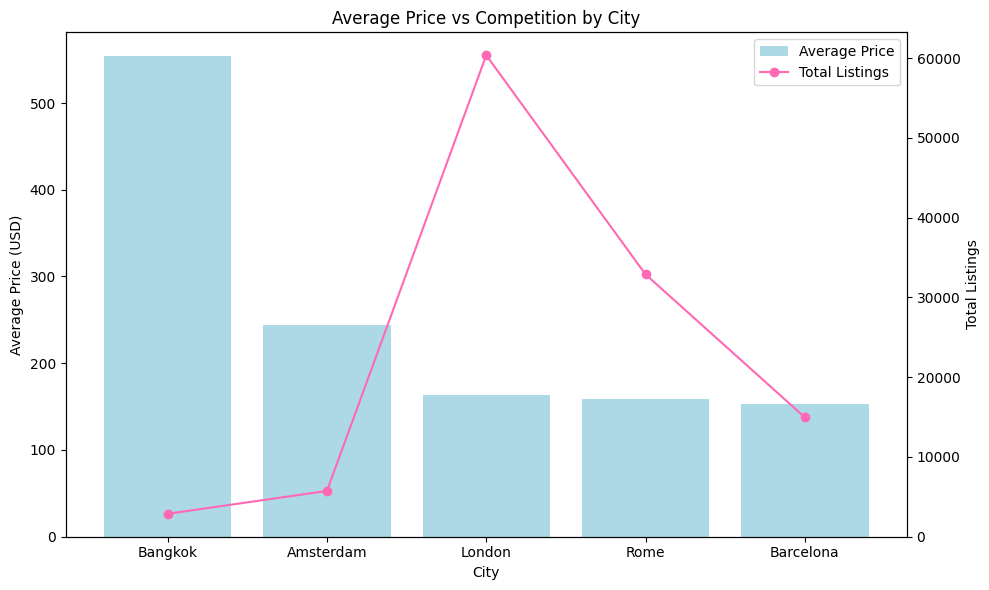

In [13]:
fix, ax1 = plt.subplots(figsize = (10, 6))

ax1.bar(city_stats.index, city_stats['mean'], color='lightblue', label='Average Price')
ax1.set_xlabel('City')
ax1.set_ylabel('Average Price (USD)')

ax2 = ax1.twinx()
ax2.plot(city_stats.index, city_stats['count'], color='hotpink', marker='o', label='Total Listings')
ax2.set_ylabel('Total Listings')

plt.title('Average Price vs Competition by City')
plt.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.show()

Looking at the chart, we can see that Bangkok has the highest average price at 553.79 USD but the lowest number of listings at 2,870. This makes sense because when there are fewer Airbnb options available, hosts can charge more since customers do not have many alternatives to choose from. London is the complete opposite with 60,348 listings and an average price of only `$163.55. Because there are so many options in London, hosts have to lower their prices to stay competitive and attract bookings. Amsterdam has similar pattern to Bangkok with fewer listings and a higher average price of 244.35 USD. Rome and Barcelona sit in the middle with moderate competition and similar prices around 153 USD to 158 USD.

Bangkok and Amsterdam seem like the better opportunity based on this data because lower competition means the hosts can charge more. In cities like London and Rome, one would need to price more carefully since there are already so many listings competing for the same customers.

Disclaimer: This analysis reflects the overall average price of city regardless of room type. Room type analysis is covered in the following section.

### Room Type Distribution & Pricing

In [14]:
room_stats = df_airbnb.groupby('room_type')['price'].agg(['mean', 'count'])
room_stats = room_stats.rename(columns={'mean': 'Avg_Price', 'count': 'Total_Listings'})
room_stats['Avg_Price'] = room_stats['Avg_Price'].round(2)
room_stats = room_stats.sort_values('Avg_Price', ascending = False)
print(room_stats)

                 Avg_Price  Total_Listings
room_type                                 
Hotel room          213.26             373
Entire home/apt     200.04           82171
Shared room         193.64             671
Private room        110.61           33565


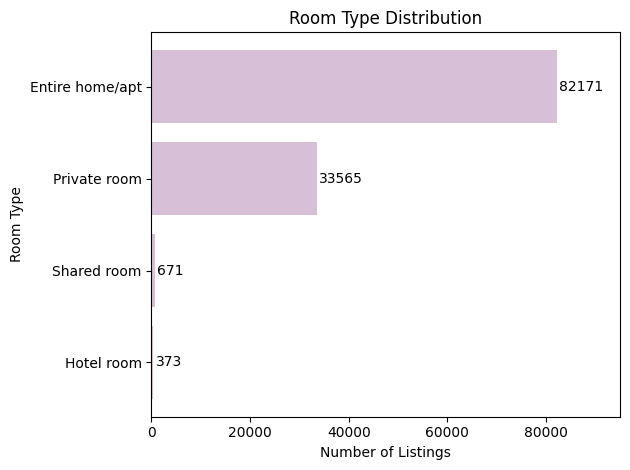

In [15]:
room_dist = room_stats.sort_values('Total_Listings', ascending=True)

room_stats_barh = plt.barh(room_dist.index, room_dist['Total_Listings'], color='thistle')
for bar in room_stats_barh:
    xval = bar.get_width()
    plt.text(xval + 500, bar.get_y() + bar.get_height()/2, int(xval), ha='left', va='center')
plt.title("Room Type Distribution")
plt.xlim(0, 95000)
plt.ylabel("Room Type")
plt.xlabel("Number of Listings")
plt.tight_layout()
plt.show()

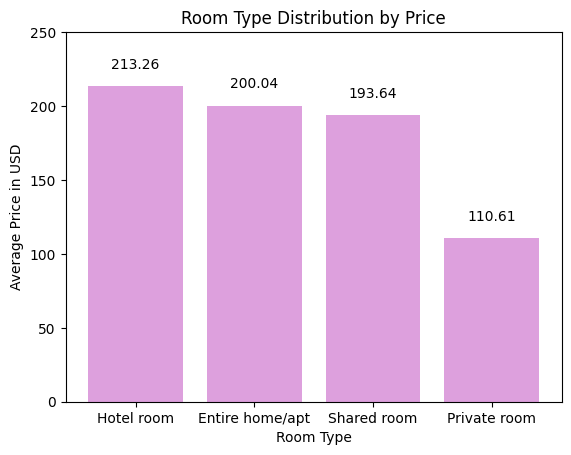

In [16]:
room_price = room_stats.sort_values('Avg_Price', ascending = False)

room_price_bar = plt.bar(room_price.index, room_price['Avg_Price'], color = 'plum')

for bar in room_price_bar:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, yval, ha='center', va='bottom')

plt.title("Room Type Distribution by Price")
plt.xlabel("Room Type")
plt.ylabel("Average Price in USD")
plt.ylim(0, 250)
plt.show()

The distribution chart shows that Entire home/apt dominates the Airbnb market with 82,171 listings, representing approximately 70% of all listings, followed by Private room with 33,565 listings. Shared room and Hotel room combined account for less than 1% of listings, suggesting these room types have very low demand.

Interestingly, the price difference between room types is not as large as expected. Hotel rooms average 213.26 USD, Entire home/apt at 200.04 USD, Shared room at 193.64 USD and Private room at 110.61 USD. The fact that Shared rooms are priced similarly to Entire home listings is surprising.

For hosts, this data suggests that listing an Entire home or Private room is the safest strategy since these two room types make up 99% of all listings, indicating that guests strongly prefer privacy over shared spaces. Private rooms offer a more budget friendly option at 110.61 USD while still maintaining strong demand.

### Neighbourhood Pricing by City

In [17]:
top_neighbourhoods = df_airbnb.groupby(['city','neighbourhood'])['price'].mean().reset_index()
print(top_neighbourhoods.head(10))
print(top_neighbourhoods.shape)

        city            neighbourhood       price
0  Amsterdam          Bijlmer-Centrum  144.514286
1  Amsterdam             Bijlmer-Oost  157.363636
2  Amsterdam            Bos en Lommer  204.674330
3  Amsterdam   Buitenveldert - Zuidas  217.933333
4  Amsterdam             Centrum-Oost  270.411449
5  Amsterdam             Centrum-West  264.876190
6  Amsterdam   De Aker - Nieuw Sloten  185.714286
7  Amsterdam   De Baarsjes - Oud-West  261.002051
8  Amsterdam  De Pijp - Rivierenbuurt  266.609449
9  Amsterdam    Gaasperdam - Driemond  140.866667
(191, 3)


In [18]:
top5_neighbourhoods = top_neighbourhoods.groupby('city').apply(
    lambda x: x.nlargest(5, 'price'),
    include_groups=False
).reset_index(level=0).reset_index(drop=True)

print(top5_neighbourhoods.columns)
print(top5_neighbourhoods.head())

Index(['city', 'neighbourhood', 'price'], dtype='object')
        city            neighbourhood       price
0  Amsterdam                     Zuid  270.701671
1  Amsterdam             Centrum-Oost  270.411449
2  Amsterdam  De Pijp - Rivierenbuurt  266.609449
3  Amsterdam             Centrum-West  264.876190
4  Amsterdam   De Baarsjes - Oud-West  261.002051


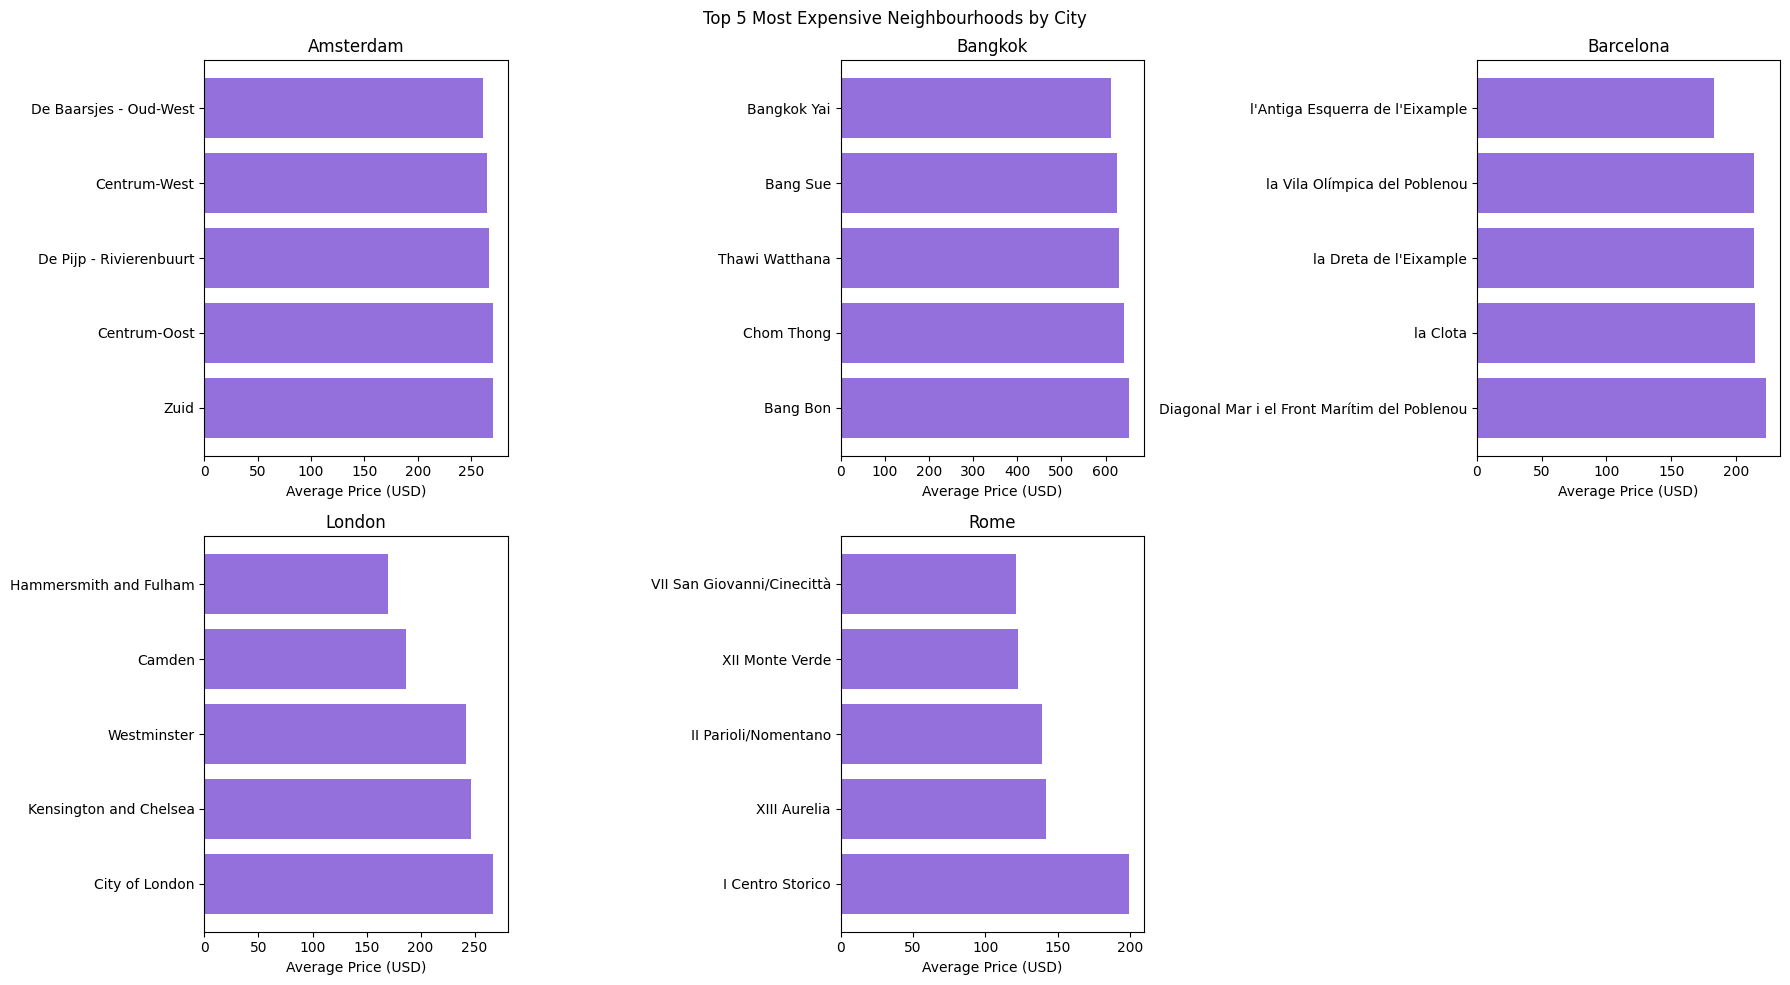

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cities = top5_neighbourhoods['city'].unique()

for idx, city in enumerate(cities):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    city_data = top5_neighbourhoods[top5_neighbourhoods['city'] == city]
    
    ax.barh(city_data['neighbourhood'], city_data['price'], color='mediumpurple')
    ax.set_title(city)
    ax.set_xlabel('Average Price (USD)')

axes[1, 2].set_visible(False)

plt.suptitle('Top 5 Most Expensive Neighbourhoods by City')
plt.tight_layout()
plt.show()

Looking at the top 5 most expensive neighbourhoods per city, Bangkok consistently domincates with its most expensive neighbourhood, Bang Bon, averaging 654 USD per night. This is consistent with our earlier finding that Bangkok has the fewest listings, allowing hosts to command significantly higher prices due to lower competition.

Rome has the lowest neighbourhood prices among all 5 cities, with its most expensive neighbourhood, Centro Storico, averaging only 199 USD. Amsterdam and London follow with top neighbourhoods around 265-270 USD, while Barcelona sits slightly lower at around 222 USD. An interesting finding is that even in competitive cities like London, premium neighbourhoods such asCity of London and Kensington and Chelsea still command significantly higher prices than the city average of 163 USD. This suggests that location within a city is just as important as the city itself. For hosts, this data highlights that choosing the right neighbourhood is critical. Even in highly competitive markets like London, listing in a premium neighbourhood can help justify higher pricing and attarct guests willing to pay more.

### Host Type & Pricing Power

In [25]:
print(df_airbnb['calculated_host_listings_count'].describe())
print(df_airbnb['calculated_host_listings_count'].value_counts().head(10))

count    116780.000000
mean         21.414386
std          63.336998
min           1.000000
25%           1.000000
50%           3.000000
75%          12.000000
max         514.000000
Name: calculated_host_listings_count, dtype: float64
calculated_host_listings_count
1     42643
2     13798
3      7807
4      5750
5      3884
6      3681
7      2323
8      2141
9      1791
10     1475
Name: count, dtype: int64


In [28]:
conditions = [
    df_airbnb['calculated_host_listings_count'] == 1,
    df_airbnb['calculated_host_listings_count'] <= 5,
    df_airbnb['calculated_host_listings_count'] > 5
]

categories = ['Single Host', 'Small Multi Host', 'Professional Host']

df_airbnb['host_type'] = np.select(conditions, categories, default = 'Single Host')
print(df_airbnb['host_type'].value_counts())

host_type
Professional Host    42898
Single Host          42643
Small Multi Host     31239
Name: count, dtype: int64


In [34]:
host_type_avg = df_airbnb.groupby('host_type')['price'].mean().round(2).reset_index()
host_type_avg = host_type_avg.rename(columns={'price': 'Avg_Price'})
host_type_avg = host_type_avg.sort_values('Avg_Price', ascending = False)
print(host_type_avg)

           host_type  Avg_Price
0  Professional Host     201.21
1        Single Host     159.27
2   Small Multi Host     158.01


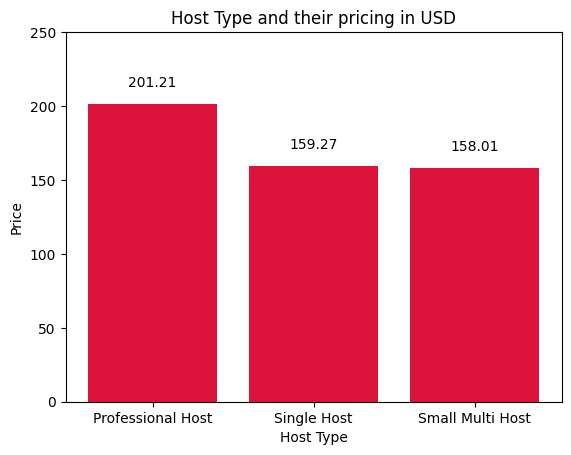

In [48]:
host_type_stats = plt.bar(host_type_avg['host_type'], host_type_avg['Avg_Price'], color = 'crimson')

for bar in host_type_stats:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, yval, ha = 'center', va = 'bottom')

plt.title("Host Type and their pricing in USD")
plt.xlabel("Host Type")
plt.ylabel("Price")
plt.ylim(0, 250)
plt.show()

Professional hosts charge the highest average price at 201.21 USD per night, significantly more than Single hosts at 159.27 USD and Small Multi hosts at 158.01 USD. This premium likely reflects the experience and expertise professional hosts bring, including better property management, optimized pricing strategies, and higher quality listings that guests are willing to pay more for.

Interestingly, Single hosts and Small Multi hosts are nearly identical in pricing with only a 1.26 USD difference, suggesting that simply adding more listings does not automatically allow hosts to charge more. The real pricing advantage only appears when hosts reach professional scale with 6 or more listings.

For new hosts, this data suggests that growing from a single listing to a few listings may not significantly impact pricing power. However, scaling to a professional level could justify charging approximately 42 USD more per night, which adds up significantly over time.
Note: These averages are influenced by city and room type, as professional hosts may be concentrated in higher priced cities like Bangkok and Amsterdam.

### Availability vs Reviews

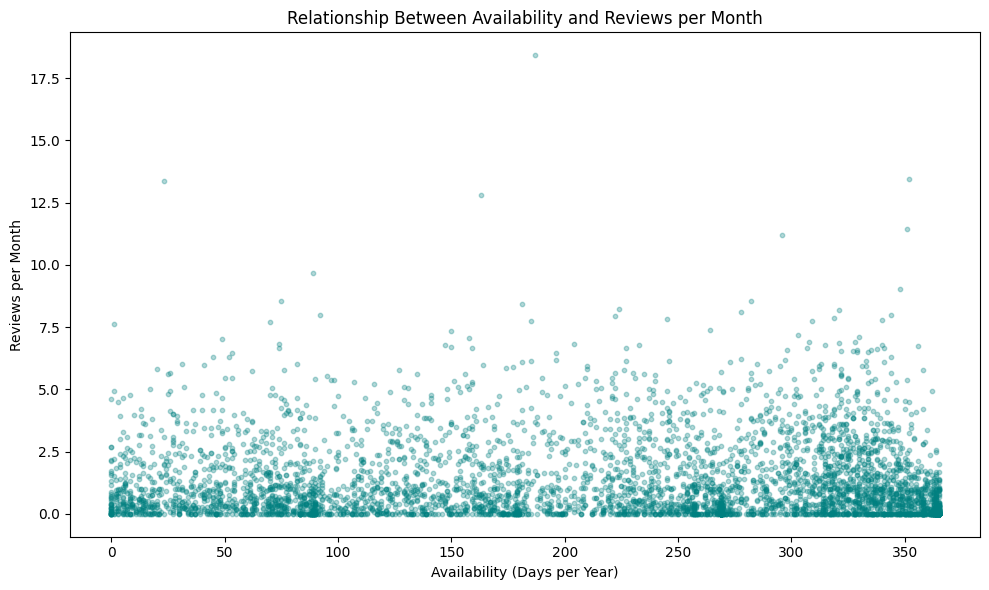

In [51]:
df_sample = df_airbnb.sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df_sample['availability_365'],
    df_sample['reviews_per_month'],
    alpha=0.3,
    color='teal',
    s=10
)
ax.set_title('Relationship Between Availability and Reviews per Month')
ax.set_xlabel('Availability (Days per Year)')
ax.set_ylabel('Reviews per Month')
plt.tight_layout()
plt.show()

The scatter plot shows that listings with lower availability tend to have higher reviews per month, suggesting that more popular listings get booked quickly and therefore have less availability remaining. Listings with high availability and low reviews may indicate newer or less popular listings that struggle to attract consistent bookings. For hosts, this suggests that a highly available listing with few reviews may need pricing adjustments or improved listing quality to attract more guests.

### Conclusion & Key Findings
- Bangkok offers the best hosting opportunity with the highest average price at 553.79 USD and the lowest competition with only 2,870 listings
- Entire home/apt dominates the market at 70% of all listings, confirming guests strongly prefer privacy
- Professional hosts with 6 or more listings charge approximately 42 USD more per night than single listing hosts
- Premium neighbourhoods exist even in competitive cities and location within a city matters as much as the city itself
- Listings with high availability and low reviews may need pricing adjustments or improved listing quality

### Disclaimers & Limitations
- Paris and Sydney excluded due to insufficient pricing data
- Price outliers removed using IQR method keeping listings between 10 and 714 USD per night
- Availability vs Reviews analysis based on a random sample of 5,000 listings
- Results may vary by season and are based on a single data snapshot